## 11.4. Stochastic  Gradient Descent (SGD)

In [2]:
%matplotlib inline
import math
import torch
from d2l import torch as d2l

### 11.4.1. Stochastic  Gradient Descent (SGD)

Given $n$ samples in training set, suppose $f_i(\textbf{x})$ is loss function of training sample of index $i$

$$
f(\textbf{x}) = \frac{1}{n} \sum_{i=1}^nf_i(\textbf{x})
$$

$$
∇f(\textbf{x}) = \frac{1}{n} \sum_{i=1}^n∇f_i(\textbf{x})
$$

$$
\textbf{x} \gets \textbf{x} - η∇f_i(\textbf{x})
$$

$$
\mathbb{E}_i∇f_i(\textbf{x}) = \frac{1}{n}\sum_{i=1}^n∇f_i(\textbf{x}) = ∇ f(\textbf{x})
$$

epoch 50, x1: -0.181512, x2: 0.060199


c:\Users\fanyu\miniconda3\envs\d2l\lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


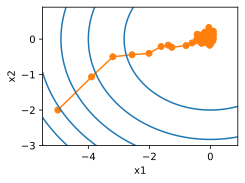

In [3]:
def f(x1, x2): # tgt func
  return x1 ** 2 + 2 * x2 ** 2

def f_grad(x1, x2): # tgt func
  return 2 * x1, 4 * x2

def sgd(x1, x2, s1, s2, f_grad):
  g1, g2 = f_grad(x1, x2)
  # simulate noise grad
  g1 += torch.normal(0.0, 1, (1,)).item()
  g2 += torch.normal(0.0, 1, (1,)).item()
  eta_t = eta * lr()
  return (x1 - eta_t * g1, x2 - eta_t * g2, 0, 0)

def constant_lr():
  return 1

eta = 0.1
lr = constant_lr # constant learning rate
d2l.show_trace_2d(f, d2l.train_2d(sgd, steps=50, f_grad=f_grad))

### 11.4.2. Dynamic Learning Rate

$$
\begin{aligned}
\eta(t) &= η_i \text{ if } t_i ≤ t ≤ t_{i+1} &\text{ 分段常数 } \\ 
η(t) &= η_0 ⋅ e^{-λ}t &\text{ 指数衰减 } \\ 
η(t) &= η_0 ⋅ (βt + 1)^{-α} &\text{ 多项式衰减 }
\end{aligned}
$$

epoch 1000, x1: -0.898979, x2: -0.113129


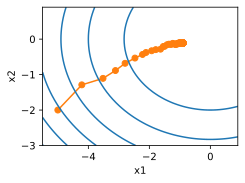

In [4]:
def exponential_lr():
  # define outer of funct, and update global var inner
  global t
  t += 1
  return math.exp(-0.1 * t)

t = 1
lr = exponential_lr
d2l.show_trace_2d(f, d2l.train_2d(sgd, steps=1000, f_grad=f_grad))

epoch 50, x1: -0.243930, x2: 0.006746


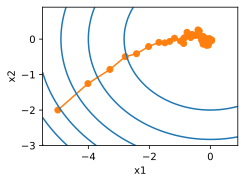

In [5]:
def polynomial_lr():
  # 在函数外部定义，而在内部更新的全局变量
  global t
  t += 1
  return (1 + 0.1 * t) ** (-0.5)

t = 1
lr = polynomial_lr
d2l.show_trace_2d(f, d2l.train_2d(sgd, steps=50, f_grad=f_grad))

### 11.4.3. Convergence Analysis of Convex Target 

$$
\textbf{x}_{t+1} = \textbf{x}_t - η_t∂_{\textbf{x}}f(\textbf{ξ}_t, \textbf{x})
$$

$$
R(\textbf{x}) = E_{\textbf{ξ}}[f(\textbf{ξ}, \textbf{x})]
$$

$$
\begin{aligned}
  &||\textbf{x}_{t+1} - \textbf{x}^*||^2 \\ 
= &||\textbf{x}_t - η_t∂_{\textbf{x}}f(\textbf{ξ}_t, \textbf{x}) - \textbf{x}^*||^2 \\ 
= &||\textbf{x}_t - \textbf{x}^*||^2 + η^2_t||∂_{\textbf{x}}f(\textbf{ξ}_t, \textbf{x})||^2 - 2η_t⟨\textbf{x}_t - \textbf{x}^*, ∂_{\textbf{x}}f(\textbf{ξ}_t, \textbf{x})⟩
\end{aligned}
$$

$$
η^2_t||∂_{\textbf{x}}f(\textbf{ξ}_t, \textbf{x})||^2 ≤ η_t^2L^2
$$

$$
f(\textbf{ξ}_t, \textbf{x}^*) ≥ f(\textbf{ξ}_t, \textbf{x}_t) + ⟨\textbf{x}^* - \textbf{x}_t, ∂_{\textbf{x}}f(\textbf{ξ}_t, \textbf{x}_t)⟩
$$

$$
||\textbf{x}_t, \textbf{x}^*||^2 - ||\textbf{x}_{t+1}, \textbf{x}^*||^2 ≥ 2η_t(f(\textbf{ξ}_t, \textbf{x}_t) - f(\textbf{ξ}_t, \textbf{x}^*)) - η_t^2L^2
$$

$$
E[||\textbf{x}_t - \textbf{x}^*||^2] - E[||\textbf{x}_{t+1} - \textbf{x}^*||^2] ≥ 2η_t[E[R(\textbf{x}_t)] - R^*] - η_t^2L^2
$$

$$
||\textbf{x}_1 - \textbf{x}^*||^2 ≥ 2(\sum_{t=1}^Tη_t)[E[R(\textbf{x}_t)] - R^*] - L^2\sum_{t=1}^Tη_t^2
$$

$$
\bar{\textbf{x}} \stackrel{ref}{=} \frac{\sum_{t=1}^Tη_t\textbf{x}_t}{\sum_{t=1}^Tη_t}
$$

$$
E(\frac{\sum_{t=1}^Tη_tR(\textbf{x}_t)}{\sum_{t=1}^Tη_t}) = \frac{\sum_{t=1}^Tη_tE[R(\textbf{x}_t)]}{\sum_{t=1}^Tη_t} = E[R(\textbf{x}_t)]
$$

$$
\sum_{t=1}^Tη_tE[R(\textbf{x}_t)] ≥ \sum_{t=1}^Tη_tE[R(\bar{\textbf{x}})]
$$

$$
[E[\bar{\textbf{x}}]] - R^* ≤ \frac{r^2 + L^2\sum_{t=1}^T η_t^2}{2\sum_{t=1}^Tη_t}
$$

### 11.4.4. Stochastic Gradient Descent and Limited Sample

$$
P(\text{choose} i) = 1 - P(\text{omit} i) = 1 - (1 - 1/n)^n ≈ 1 - e^{-1} ≈ 0.63
$$

$$
\left(\begin{aligned}
n \\ 
1
\end{aligned}\right) \frac1n
(1 - \frac1n)^{n-1} = \frac{n}{n - 1}(1 - \frac1n)^n ≈ e^{-1} ≈ 0.37
$$